<a href="https://colab.research.google.com/github/edwardcalvinvazc-maker/Music-Recommendation-Engine/blob/main/Music_Recommendation_LTR_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# =============================================================================
# 0. IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.metrics import (
    roc_auc_score, log_loss,
    mean_squared_error, mean_absolute_error, r2_score,
    ndcg_score
)
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb


In [ ]:
from scipy.stats import randint, uniform, loguniform

In [11]:
# =============================================================================
# 1. LOAD DATA
# =============================================================================
music_data = pd.read_csv('/content/M+U_dataset.csv')
print(f"Total rows in raw dataset: {music_data.shape[0]}")

Total rows in raw dataset: 70129


In [12]:
print('\nMissing values per column:')
print(music_data.isnull().sum().to_string())


Missing values per column:
timestamp                   0
user_id                     0
age                         0
gender                      0
location                    0
device_type                 0
listening_time_mins         0
sessions_per_day            0
time_of_day                 0
day_of_week                 0
preferred_genre             0
preferred_artist            0
recent_skip_rate            0
subscription_type           0
song_id                     0
title                       0
artist                      0
album                       0
genre                       0
release_year                0
language                    0
duration_sec                0
popularity                  0
explicit                    0
tempo                       0
key                         0
mode                        0
time_signature              0
energy                      0
danceability                0
acousticness                0
instrumentalness            0
liveness    

In [16]:
# =============================================================================
# 3. FEATURE / TARGET DEFINITION
# =============================================================================
classifier_target = 'liked'
regressor_target  = 'time_spent_on_song'

# Preserve user_id for per-user NDCG grouping — kept in a separate index series,
# NOT passed as a model feature.
user_id_col = 'user_id'

# Columns that are identifiers or free-text — excluded from the feature matrix.
id_columns = ['timestamp', 'user_id', 'song_id', 'title', 'artist', 'album', 'preferred_artist']

df = music_data.copy()

y_class     = df[classifier_target]
y_reg       = df[regressor_target]
y_reg_raw   = df['time_spent_on_song']   # original seconds, used for relevance labels & sanity check
user_ids    = df[user_id_col] if user_id_col in df.columns else None

columns_to_drop = [classifier_target, regressor_target, 'time_spent_on_song', 'time_spent_log'] + id_columns
X = df.drop(columns=[c for c in columns_to_drop if c in df.columns], errors='ignore')


print(f"\nFeature matrix shape: {X.shape}")


categorical_features = [
    'gender', 'location', 'device_type', 'time_of_day', 'day_of_week',
    'preferred_genre', 'subscription_type', 'genre', 'language', 'explicit',
    'mode', 'lyrics_sentiment', 'emotion_tag', 'context_type'
]
for col in categorical_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

X.info()


Feature matrix shape: (70129, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70129 entries, 0 to 70128
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   age                       70129 non-null  int64   
 1   gender                    70129 non-null  category
 2   location                  70129 non-null  category
 3   device_type               70129 non-null  category
 4   listening_time_mins       70129 non-null  int64   
 5   sessions_per_day          70129 non-null  int64   
 6   time_of_day               70129 non-null  category
 7   day_of_week               70129 non-null  category
 8   preferred_genre           70129 non-null  category
 9   recent_skip_rate          70129 non-null  float64 
 10  subscription_type         70129 non-null  category
 11  genre                     70129 non-null  category
 12  release_year              70129 non-null  int64   
 13  language   

In [17]:
# =============================================================================
# 4. TRAIN / VALIDATION / TEST SPLIT
# =============================================================================
# 60 % train  |  20 % validation (for LTR weight sweep)  |  20 % test (touched once)
X_train_val, X_test, y_class_train_val, y_class_test, \
y_reg_train_val, y_reg_test, y_reg_raw_train_val, y_reg_raw_test = train_test_split(
    X, y_class, y_reg, y_reg_raw,
    test_size=0.20,
    random_state=42,
    stratify=y_class        # preserve class balance
)

X_train, X_val, y_class_train, y_class_val, \
y_reg_train, y_reg_val, y_reg_raw_train, y_reg_raw_val = train_test_split(
    X_train_val, y_class_train_val, y_reg_train_val, y_reg_raw_train_val,
    test_size=0.25,          # 0.25 × 0.80 = 0.20 of total
    random_state=42,
    stratify=y_class_train_val
)

print(f"\nTrain:      {X_train.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test:       {X_test.shape[0]} rows")

# Preserve user_ids aligned to each split (needed for per-user NDCG)
if user_ids is not None:
    uid_train_val, uid_test = train_test_split(
        user_ids, test_size=0.20, random_state=42, stratify=y_class
    )
    uid_train, uid_val = train_test_split(
        uid_train_val, test_size=0.25, random_state=42, stratify=y_class_train_val
    )


Train:      42077 rows
Validation: 14026 rows
Test:       14026 rows



# 5. RANDOMIZED SEARCH CV TUNING — CLASSIFIER


In [19]:
from scipy.stats import randint, uniform, loguniform

print("\n" + "="*60)
print("CLASSIFIER HYPERPARAMETER SEARCH (RandomizedSearchCV)")
print("="*60)

# Define the parameter space for RandomizedSearchCV
param_dist_class = {
    'n_estimators':    randint(100, 601), # Equivalent to hp.quniform(100, 600, 50)
    'learning_rate':   loguniform(0.005, 0.3), # Equivalent to hp.loguniform(np.log(0.005), np.log(0.3))
    'max_depth':       randint(3, 11),   # Equivalent to hp.quniform(3, 10, 1)
    'subsample':       uniform(0.5, 0.5), # Equivalent to hp.uniform(0.5, 1.0)
    'colsample_bytree':uniform(0.5, 0.5), # Equivalent to hp.uniform(0.5, 1.0)
    'gamma':           uniform(0.0, 1.0), # Equivalent to hp.uniform(0.0, 1.0)
    'reg_alpha':       loguniform(1e-4, 10), # Equivalent to hp.loguniform(np.log(1e-4), np.log(10))
    'reg_lambda':      loguniform(1e-4, 10), # Equivalent to hp.loguniform(np.log(1e-4), np.log(10))
    'min_child_weight':randint(1, 11)   # Equivalent to hp.quniform(1, 10, 1)
}

# Initialize XGBClassifier
clf = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    enable_categorical=True,
    random_state=42,
    n_jobs=1
)

# Set up StratifiedKFold for cross-validation
cv_class = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform RandomizedSearchCV
random_search_class = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist_class,
    n_iter=60, # Number of parameter settings that are sampled
    scoring='roc_auc',
    cv=cv_class,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_class.fit(X_train, y_class_train)

best_params_class = random_search_class.best_params_
print("\nBest classifier hyperparameters (RandomizedSearchCV):")
for k, v in best_params_class.items():
    print(f"  {k}: {v:.6g}" if isinstance(v, float) else f"  {k}: {v}")

print(f"Best ROC AUC on train data (cross-validated): {random_search_class.best_score_:.4f}")


CLASSIFIER HYPERPARAMETER SEARCH (RandomizedSearchCV)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best classifier hyperparameters (RandomizedSearchCV):
  colsample_bytree: 0.875436
  gamma: 0.754543
  learning_rate: 0.00762676
  max_depth: 3
  min_child_weight: 1
  n_estimators: 161
  reg_alpha: 0.0303953
  reg_lambda: 0.00887341
  subsample: 0.648818
Best ROC AUC on train data (cross-validated): 0.5048



# 6. RANDOMIZED SEARCH CV TUNING — REGRESSOR


In [20]:
print("\n" + "="*60)
print("REGRESSOR HYPERPARAMETER SEARCH (RandomizedSearchCV)")
print("="*60)

# Define the parameter space for RandomizedSearchCV
param_dist_reg = {
    'n_estimators':    randint(100, 601),
    'learning_rate':   loguniform(0.005, 0.3),
    'max_depth':       randint(3, 11),
    'subsample':       uniform(0.5, 0.5),
    'colsample_bytree':uniform(0.5, 0.5),
    'gamma':           uniform(0.0, 1.0),
    'reg_alpha':       loguniform(1e-4, 10),
    'reg_lambda':      loguniform(1e-4, 10),
    'min_child_weight':randint(1, 11)
}

# Initialize XGBRegressor
reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    enable_categorical=True,
    random_state=42,
    n_jobs=1
)

# Set up KFold for cross-validation
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform RandomizedSearchCV
random_search_reg = RandomizedSearchCV(
    estimator=reg,
    param_distributions=param_dist_reg,
    n_iter=60, # Number of parameter settings that are sampled
    scoring='neg_root_mean_squared_error',
    cv=cv_reg,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_reg.fit(X_train, y_reg_train)

best_params_reg = random_search_reg.best_params_
print("\nBest regressor hyperparameters (RandomizedSearchCV):")
for k, v in best_params_reg.items():
    print(f"  {k}: {v:.6g}" if isinstance(v, float) else f"  {k}: {v}")

print(f"Best RMSE on train data (cross-validated): {-random_search_reg.best_score_:.4f}")


REGRESSOR HYPERPARAMETER SEARCH (RandomizedSearchCV)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best regressor hyperparameters (RandomizedSearchCV):
  colsample_bytree: 0.659488
  gamma: 0.844875
  learning_rate: 0.00549985
  max_depth: 4
  min_child_weight: 3
  n_estimators: 204
  reg_alpha: 0.0302125
  reg_lambda: 0.291375
  subsample: 0.674168
Best RMSE on train data (cross-validated): 29.9206



# 7. MODEL EVALUATION ON TEST DATA


## 7.1 Classifier Evaluation

In [21]:
# Initialize and train the best classifier
best_clf = xgb.XGBClassifier(
    **best_params_class,
    objective='binary:logistic',
    tree_method='hist',
    enable_categorical=True,
    random_state=42,
    n_jobs=1
)
best_clf.fit(X_train, y_class_train)

# Predict probabilities on the test set
y_class_pred_proba = best_clf.predict_proba(X_test)[:, 1]

# Predict classes on the test set
y_class_pred = best_clf.predict(X_test)

# Evaluate classifier performance
roc_auc = roc_auc_score(y_class_test, y_class_pred_proba)
logloss = log_loss(y_class_test, y_class_pred_proba)

print(f"\nClassifier Test Metrics:")
print(f"  ROC AUC: {roc_auc:.4f}")
print(f"  Log Loss: {logloss:.4f}")


Classifier Test Metrics:
  ROC AUC: 0.4973
  Log Loss: 0.6094


## 7.2 Regressor Evaluation

In [22]:
# Initialize and train the best regressor
best_reg = xgb.XGBRegressor(
    **best_params_reg,
    objective='reg:squarederror',
    tree_method='hist',
    enable_categorical=True,
    random_state=42,
    n_jobs=1
)
best_reg.fit(X_train, y_reg_train)

# Predict on the test set
y_reg_pred = best_reg.predict(X_test)

# Evaluate regressor performance
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae = mean_absolute_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)

print(f"\nRegressor Test Metrics:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  R2 Score: {r2:.4f}")


Regressor Test Metrics:
  RMSE: 30.2854
  MAE: 24.0909
  R2 Score: -0.0007


## 7.3 NDCG Evaluation (Classifier and Regressor)

In [23]:
# Calculate relevance labels for NDCG (using raw time spent)
# For classifier, relevance is 'liked' (0 or 1)
# For regressor, relevance could be binarized or scaled 'time_spent_on_song' from y_reg_raw_test

# Ensure user_ids are aligned for the test set
if user_ids is not None:
    # Assuming uid_test is already split and aligned with X_test, y_class_test, y_reg_test
    # Convert uid_test to DataFrame for merging/grouping easily if it's a Series
    uid_test_df = pd.DataFrame({'user_id': uid_test.values}, index=X_test.index)
else:
    print("User IDs not available for NDCG calculation.")

# Prepare data for NDCG calculation (user-wise grouping)
ndcg_df = pd.DataFrame({
    'user_id': uid_test_df['user_id'],
    'true_liked': y_class_test,
    'pred_liked_proba': y_class_pred_proba,
    'true_time_spent': y_reg_raw_test, # Using raw time spent for regressor relevance
    'pred_time_spent': y_reg_pred
})

# Calculate NDCG@5 for Classifier (based on 'liked' prediction probabilities)
ndcg_scores_clf = []
for user_id_val in ndcg_df['user_id'].unique():
    user_data = ndcg_df[ndcg_df['user_id'] == user_id_val].sort_values(by='pred_liked_proba', ascending=False)
    if len(user_data) > 0:
        # Ensure we have enough items for NDCG@5, pad if necessary
        k = min(5, len(user_data))
        if k > 0:
            # true_relevance, predicted_scores
            ndcg_scores_clf.append(ndcg_score(np.asarray([user_data['true_liked'].head(k).values]),
                                              np.asarray([user_data['pred_liked_proba'].head(k).values]), k=k))

# Calculate NDCG@5 for Regressor (based on predicted time spent)
ndcg_scores_reg = []
for user_id_val in ndcg_df['user_id'].unique():
    user_data = ndcg_df[ndcg_df['user_id'] == user_id_val].sort_values(by='pred_time_spent', ascending=False)
    if len(user_data) > 0:
        k = min(5, len(user_data))
        if k > 0:
            # true_relevance, predicted_scores
            # For regressor, true relevance is raw time spent. Higher time spent = more relevant.
            ndcg_scores_reg.append(ndcg_score(np.asarray([user_data['true_time_spent'].head(k).values]),
                                              np.asarray([user_data['pred_time_spent'].head(k).values]), k=k))

print(f"\nAverage NDCG@5 for Classifier: {np.mean(ndcg_scores_clf):.4f}")
print(f"Average NDCG@5 for Regressor: {np.mean(ndcg_scores_reg):.4f}")


Average NDCG@5 for Classifier: 0.4850
Average NDCG@5 for Regressor: 0.9563



# 8. PREDICTIONS ON VALIDATION SET


In [24]:
# Predict probabilities for the validation set using the best classifier
val_clf_probs = best_clf.predict_proba(X_val)[:, 1]

# Predict durations for the validation set using the best regressor
val_reg_seconds = best_reg.predict(X_val)

print("Validation set predictions generated.")

Validation set predictions generated.



# 9. LTR WEIGHT SWEEP ON VALIDATION SET


LTR WEIGHT SWEEP (validation set)
Duration cap (train 95th-percentile): 209.0 s

Weight sweep results (top 5 by NDCG@10):
  w1   w2  ndcg@10
0.40 0.60 0.633775
0.70 0.30 0.628971
0.35 0.65 0.628798
0.90 0.10 0.628417
0.80 0.20 0.628021

Chosen weights: w1 (liked prob) = 0.40,  w2 (duration) = 0.60


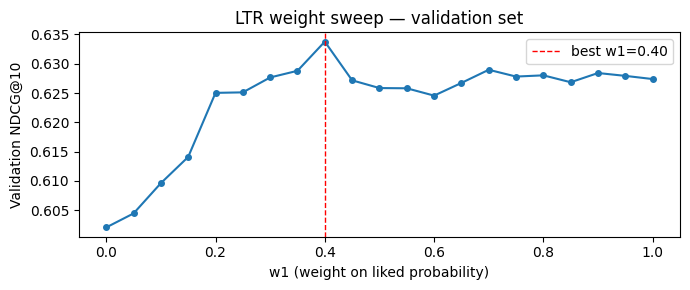

In [25]:
print("\n" + "="*60)
print("LTR WEIGHT SWEEP (validation set)")
print("="*60)

# Empirical 95th-percentile cap for duration normalization.
# A quantile-based cap is more robust than a fixed 240 s because it adapts
# to the actual distribution in your dataset.
duration_cap = float(np.percentile(y_reg_raw_train, 95))
print(f"Duration cap (train 95th-percentile): {duration_cap:.1f} s")

# Ground-truth relevance labels (same definition used at final test evaluation)
def make_relevance(true_likes, true_seconds):
    return np.where(
        (true_likes == 1) & (true_seconds >= 120), 2,
        np.where((true_likes == 1) | (true_seconds >= 120), 1, 0)
    )

val_relevance = make_relevance(y_class_val.values, y_reg_raw_val.values)
val_norm_dur  = np.clip(val_reg_seconds / duration_cap, 0.0, 1.0)

# If we have user_ids, compute per-user NDCG; otherwise fall back to flat NDCG.
def per_user_ndcg(user_ids_arr, true_rel, scores, k=10):
    """
    Groups predictions by user, computes NDCG@k for each user that has
    at least k candidates, and returns the macro-average.
    If user_ids_arr is None, falls back to a single flat NDCG computation.
    """
    if user_ids_arr is None:
        # Ensure true_rel and scores are 2D arrays for ndcg_score
        return ndcg_score(np.asarray([true_rel]), np.asarray([scores]), k=k)

    users      = np.asarray(user_ids_arr)
    true_rel   = np.asarray(true_rel)
    scores     = np.asarray(scores)
    unique_u   = np.unique(users)
    user_ndcgs = []
    for u in unique_u:
        mask = users == u
        # Filter out users with insufficient candidates
        if mask.sum() < k:
            continue
        # Ensure true_rel and scores subsets are 2D arrays
        user_ndcgs.append(
            ndcg_score(true_rel[mask].reshape(1, -1), scores[mask].reshape(1, -1), k=k)
        )
    if not user_ndcgs:
        return float('nan')
    return float(np.mean(user_ndcgs))

# Sweep w1 from 0.0 to 1.0 in steps of 0.05; w2 = 1 - w1
w1_candidates  = np.arange(0.0, 1.05, 0.05)
sweep_results  = []

uid_val_arr = uid_val.values if user_ids is not None else None

for w1 in w1_candidates:
    w2 = 1.0 - w1
    ltr_scores = w1 * val_clf_probs + w2 * val_norm_dur
    ndcg_val   = per_user_ndcg(uid_val_arr, val_relevance, ltr_scores, k=10)
    sweep_results.append({'w1': round(w1, 2), 'w2': round(w2, 2), 'ndcg@10': ndcg_val})

sweep_df = pd.DataFrame(sweep_results)
best_row = sweep_df.loc[sweep_df['ndcg@10'].idxmax()]
w1_best  = float(best_row['w1'])
w2_best  = float(best_row['w2'])

print(f"\nWeight sweep results (top 5 by NDCG@10):")
print(sweep_df.sort_values('ndcg@10', ascending=False).head(5).to_string(index=False))
print(f"\nChosen weights: w1 (liked prob) = {w1_best:.2f},  w2 (duration) = {w2_best:.2f}")

# Optional: plot the sweep
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(sweep_df['w1'], sweep_df['ndcg@10'], marker='o', markersize=4)
ax.axvline(w1_best, color='red', linestyle='--', linewidth=1, label=f'best w1={w1_best:.2f}')
ax.set_xlabel('w1 (weight on liked probability)')
ax.set_ylabel('Validation NDCG@10')
ax.set_title('LTR weight sweep — validation set')
ax.legend()
fig.tight_layout()
plt.show()


# 10. FINAL LTR EVALUATION ON TEST SET

In [29]:
print("\n" + "="*60)
print("FINAL LTR EVALUATION ON TEST SET")
print("="*60)

# Calculate ground-truth relevance for the test set
test_relevance = make_relevance(y_class_test.values, y_reg_raw_test.values)

# Normalize regressor predictions for the test set using the same duration_cap
test_norm_dur = np.clip(y_reg_pred / duration_cap, 0.0, 1.0)

# Calculate final LTR scores on the test set using the best weights
test_ltr_scores = w1_best * y_class_pred_proba + w2_best * test_norm_dur

# Get user_ids array for test set (if available)
uid_test_arr = uid_test.values if user_ids is not None else None

# Calculate NDCG@10 on the test set
final_ndcg_test = per_user_ndcg(uid_test_arr, test_relevance, test_ltr_scores, k=20)

print(f"Final LTR NDCG@10 on Test Set (w1={w1_best:.2f}, w2={w2_best:.2f}): {final_ndcg_test:.4f}")


FINAL LTR EVALUATION ON TEST SET
Final LTR NDCG@10 on Test Set (w1=0.40, w2=0.60): 0.6079


# =============================================================================
# 11. AUTOMATED LTR WEIGHT OPTIMIZATION VIA COORDINATE ASCENT
# =============================================================================


LTR WEIGHT OPTIMIZATION (COORDINATE ASCENT)

Iteration 1/10
  Current Best Weights: w1 = 0.40, w2 = 0.60
  Current Best NDCG@10 on Validation: 0.6338

Iteration 2/10
  Current Best Weights: w1 = 0.40, w2 = 0.60
  Current Best NDCG@10 on Validation: 0.6338
Converged.

Optimization finished.

Final Optimized Weights: w1 = 0.40, w2 = 0.60
Final Best NDCG@10 on Validation Set: 0.6338


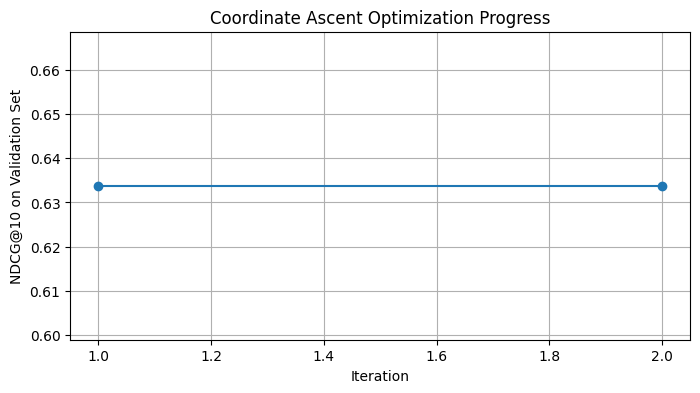

In [31]:
print("\n" + "="*60)
print("LTR WEIGHT OPTIMIZATION (COORDINATE ASCENT)")
print("="*60)

# Initial weights (can be from previous sweep or arbitrary)
w1_current = w1_best # Start with the best from the previous sweep
w2_current = w2_best # Start with the best from the previous sweep

# Define the range for sweeping w1 and w2
weight_candidates = np.arange(0.0, 1.05, 0.05)

max_iterations = 10 # Number of iterations for coordinate ascent
ndcg_history = []
w_history = []

uid_val_arr = uid_val.values if user_ids is not None else None

for iteration in range(max_iterations):
    print(f"\nIteration {iteration + 1}/{max_iterations}")

    # --- Optimize w1 (w2 is fixed) ---
    best_w1_this_step = w1_current
    best_ndcg_this_step = -1.0 # Initialize with a very low NDCG

    for w1_cand in weight_candidates:
        # Ensure w1_cand + w2_current <= 1.0 (or normalize later)
        # For coordinate ascent, we usually fix one and sweep the other, implicitly adjusting the sum.
        # Let's re-normalize such that w1 + w2 = 1 to keep it consistent with previous logic
        if w1_cand + w2_current > 1.0:
            # If w1_cand is too high, cap w2 or skip this combo
            # For simplicity, we can normalize if sum > 1, or just sweep w1 and set w2=1-w1_cand
            # Let's adjust w2 to ensure sum is 1, so effectively just sweeping w1
            w2_adjusted = 1.0 - w1_cand
            if w2_adjusted < 0: # Should not happen with np.arange(0,1.05,0.05)
                w2_adjusted = 0
        else:
            w2_adjusted = w2_current # if w1_cand + w2_current <= 1.0, keep w2 fixed and let ltr_scores be weighted sum

        ltr_scores_cand = w1_cand * val_clf_probs + w2_adjusted * val_norm_dur
        ndcg_cand = per_user_ndcg(uid_val_arr, val_relevance, ltr_scores_cand, k=10)

        if ndcg_cand > best_ndcg_this_step:
            best_ndcg_this_step = ndcg_cand
            best_w1_this_step = w1_cand

    w1_current = best_w1_this_step
    # Ensure w2 is adjusted if w1 changed (maintain w1 + w2 = 1 assumption for simplicity)
    w2_current = 1.0 - w1_current
    current_ndcg = best_ndcg_this_step # NDCG after updating w1

    # --- Optimize w2 (w1 is fixed) ---
    best_w2_this_step = w2_current
    best_ndcg_this_step = current_ndcg # Start with current NDCG

    for w2_cand in weight_candidates:
        # As above, effectively sweeping w2 and setting w1 = 1 - w2_cand
        w1_adjusted = 1.0 - w2_cand
        if w1_adjusted < 0:
            w1_adjusted = 0

        ltr_scores_cand = w1_adjusted * val_clf_probs + w2_cand * val_norm_dur
        ndcg_cand = per_user_ndcg(uid_val_arr, val_relevance, ltr_scores_cand, k=10)

        if ndcg_cand > best_ndcg_this_step:
            best_ndcg_this_step = ndcg_cand
            best_w2_this_step = w2_cand

    w2_current = best_w2_this_step
    # Ensure w1 is adjusted if w2 changed (maintain w1 + w2 = 1 assumption for simplicity)
    w1_current = 1.0 - w2_current
    current_ndcg = best_ndcg_this_step # NDCG after updating w2

    ndcg_history.append(current_ndcg)
    w_history.append({'w1': w1_current, 'w2': w2_current})

    print(f"  Current Best Weights: w1 = {w1_current:.2f}, w2 = {w2_current:.2f}")
    print(f"  Current Best NDCG@10 on Validation: {current_ndcg:.4f}")

    # Check for convergence (if NDCG hasn't improved much)
    if len(ndcg_history) > 1 and np.abs(ndcg_history[-1] - ndcg_history[-2]) < 1e-4:
        print("Converged.")
        break

print("\nOptimization finished.")
w1_final_ca = w_history[-1]['w1']
w2_final_ca = w_history[-1]['w2']
final_ndcg_ca = ndcg_history[-1]

print(f"\nFinal Optimized Weights: w1 = {w1_final_ca:.2f}, w2 = {w2_final_ca:.2f}")
print(f"Final Best NDCG@10 on Validation Set: {final_ndcg_ca:.4f}")

# Plot convergence history
fig_ca, ax_ca = plt.subplots(figsize=(8, 4))
ax_ca.plot(range(1, len(ndcg_history) + 1), ndcg_history, marker='o')
ax_ca.set_xlabel('Iteration')
ax_ca.set_ylabel('NDCG@10 on Validation Set')
ax_ca.set_title('Coordinate Ascent Optimization Progress')
ax_ca.grid(True)
plt.show()


# 12. FINAL LTR EVALUATION ON TEST SET (COORDINATE ASCENT WEIGHTS)


In [32]:
print("\n" + "="*60)
print("FINAL LTR EVALUATION ON TEST SET (COORDINATE ASCENT)")
print("="*60)

# Calculate ground-truth relevance for the test set (using make_relevance from before)
test_relevance_ca = make_relevance(y_class_test.values, y_reg_raw_test.values)

# Normalize regressor predictions for the test set using the same duration_cap
test_norm_dur_ca = np.clip(y_reg_pred / duration_cap, 0.0, 1.0)

# Calculate final LTR scores on the test set using the final optimized weights
test_ltr_scores_ca = w1_final_ca * y_class_pred_proba + w2_final_ca * test_norm_dur_ca

# Get user_ids array for test set (if available)
uid_test_arr_ca = uid_test.values if user_ids is not None else None

# Calculate NDCG@10 on the test set
final_ndcg_test_ca = per_user_ndcg(uid_test_arr_ca, test_relevance_ca, test_ltr_scores_ca, k=10)

print(f"Final LTR NDCG@10 on Test Set (w1={w1_final_ca:.2f}, w2={w2_final_ca:.2f}): {final_ndcg_test_ca:.4f}")


FINAL LTR EVALUATION ON TEST SET (COORDINATE ASCENT)
Final LTR NDCG@10 on Test Set (w1=0.40, w2=0.60): 0.6068
